# BigAlpha 2026 因子库衍生工程因子

## 因子名称
Factorlib Engineering Factor（因子库衍生工程因子）

## 核心创新
在已有的14个因子库维度上做衍生变换——交互项、比率、时序变化率。
不需要新数据，发掘因子库内部的非线性信号。

## 14维衍生信号
| 信号 | 含义 |
|------|------|
| momentum_reversal_ratio | 趋势纯度（动量/反转比）|
| value_momentum | 价值发现速度（EY变化率）|
| quality_momentum | 质量变化（ROE delta）|
| vol_change | 波动扩张/收缩 |
| turn_accel | 换手率加速度 |
| pe_pb_divergence | PE vs PB 截面排名背离 |
| netflow_smooth | 资金流5日均值（持续性）|
| lowvol_quality | 低波+质量联合排名 |
| size_value | 小盘价值交互 |
| beta_momentum | 高风险+高动量 |
| rsi_reversal | 超卖反弹（rsi×rev）|
| quality_momentum_div | 基本面滞后价差 |
| vol_turn | 投机热度（vol×turn）|
| growth_value | 成长-价值差（毛利率vs账面市值比）|

## 合规说明
- 纯截面排名合成，无ML
- 所有衍生仅使用当日及过去数据

## 输出格式
date / instrument / factor（归一化到[0,1]）

In [1]:
def main(datasources, start_date, end_date):
    """
    因子库衍生工程：14个基础维度 → 交互项/比率/时序变化 → 14维衍生信号等权合成
    纯 pandas 计算，无 SQL，不影响性能
    """
    import time, numpy as np, pandas as pd, dai, structlog
    logger = structlog.get_logger(); t0 = time.time(); eps = 1e-8
    pre_start = str(pd.to_datetime(start_date) - pd.Timedelta(days=30))

    # ---- 因子库 14维 ----
    flib = dai.query("""
    SELECT date, instrument,
        momentum_5, reversal_5, volatility_5,
        turn, total_market_cap, pe_ttm, pb,
        rsi_12, beta_000300SH_22,
        netflow_amount_rate_main,
        roe_avg_ttm, gross_profit_rate_ttm,
        debt_to_asset_lf, current_ratio_lf
    FROM bigalpha_2026_factorlib
    """, filters={'date': [pre_start, end_date]}, compression=True).df()
    flib['date'] = pd.to_datetime(flib['date'])
    flib['instrument'] = flib['instrument'].astype(str)
    cols = ['momentum_5','reversal_5','volatility_5','turn','total_market_cap',
            'pe_ttm','pb','rsi_12','beta_000300SH_22',
            'netflow_amount_rate_main','roe_avg_ttm','gross_profit_rate_ttm',
            'debt_to_asset_lf','current_ratio_lf']
    for c in cols:
        if c in flib.columns: flib[c] = pd.to_numeric(flib[c], errors='coerce')
    flib = flib.replace([np.inf, -np.inf], np.nan)
    flib['earnings_yield'] = np.where(flib['pe_ttm']>0, 1.0/flib['pe_ttm'], np.nan)
    flib['book_to_market'] = np.where(flib['pb']>0, 1.0/flib['pb'], np.nan)

    flib = flib.sort_values(['instrument','date']).reset_index(drop=True)

    # ---- 衍生信号（纯 pandas，groupby.transform 安全） ----
    g = flib.groupby('instrument')

    # 动量/反转比（趋势纯度）
    flib['momentum_reversal_ratio'] = np.where(
        flib['reversal_5'].abs()>eps,
        flib['momentum_5']/flib['reversal_5'].abs(), np.nan)

    # 价值动量：earnings_yield 变化率
    flib['value_momentum'] = g['earnings_yield'].transform(lambda x: x.diff(5)/x.shift(5).abs().clip(0.001))

    # 质量动量：roe 变化
    flib['quality_momentum'] = g['roe_avg_ttm'].transform(lambda x: x.diff(5))

    # 波动率变化
    flib['vol_change'] = g['volatility_5'].transform(lambda x: x/x.shift(5)-1)

    # 换手率加速度
    flib['turn_accel'] = g['turn'].transform(lambda x: x.diff(5))

    # PE-PB背离（价值因子内部背离）
    ey_rk = flib.groupby('date')['earnings_yield'].rank(pct=True, na_option='bottom')
    bm_rk = flib.groupby('date')['book_to_market'].rank(pct=True, na_option='bottom')
    flib['pe_pb_divergence'] = ey_rk - bm_rk

    # 资金流持续性
    flib['netflow_smooth'] = g['netflow_amount_rate_main'].transform(lambda x: x.rolling(5, min_periods=1).mean())

    # 低波+质量联合
    vol_rk = flib.groupby('date')['volatility_5'].rank(pct=True, na_option='top')
    roe_rk = flib.groupby('date')['roe_avg_ttm'].rank(pct=True, na_option='bottom')
    flib['lowvol_quality'] = vol_rk + roe_rk

    # 规模-价值交互
    size_rk = flib.groupby('date')['total_market_cap'].rank(pct=True, na_option='top')
    flib['size_value'] = size_rk * bm_rk

    # Beta-动量交互
    beta_rk = flib.groupby('date')['beta_000300SH_22'].rank(pct=True, na_option='top')
    mom_rk = flib.groupby('date')['momentum_5'].rank(pct=True, na_option='bottom')
    flib['beta_momentum'] = beta_rk * mom_rk

    # RSI-反转联合
    rsi_rk = flib.groupby('date')['rsi_12'].rank(pct=True, na_option='top')
    rev_rk = flib.groupby('date')['reversal_5'].rank(pct=True, na_option='bottom')
    flib['rsi_reversal'] = rsi_rk * rev_rk

    # 质量-动量背离
    flib['quality_momentum_div'] = roe_rk - mom_rk

    # 波动-换手交互
    flib['vol_turn'] = vol_rk * flib.groupby('date')['turn'].rank(pct=True, na_option='top')

    # 成长-价值差
    gross_rk = flib.groupby('date')['gross_profit_rate_ttm'].rank(pct=True, na_option='bottom')
    flib['growth_value'] = gross_rk - bm_rk

    all_signal = [
        'momentum_reversal_ratio', 'value_momentum', 'quality_momentum',
        'vol_change', 'turn_accel', 'pe_pb_divergence',
        'netflow_smooth', 'lowvol_quality', 'size_value',
        'beta_momentum', 'rsi_reversal', 'quality_momentum_div',
        'vol_turn', 'growth_value'
    ]
    all_signal = [s for s in all_signal if s in flib.columns]
    flib = flib.replace([np.inf, -np.inf], np.nan)

    flib = flib[flib['date'] >= pd.to_datetime(start_date)]

    # 截面排名等权
    all_rk = []
    for s in all_signal:
        d = f'r_{s}'
        flib[d] = flib.groupby('date')[s].rank(pct=True, na_option='bottom')
        all_rk.append(d)
    flib['factor'] = flib[all_rk].sum(axis=1)/len(all_rk)

    # 对齐成分股
    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                     filters={'date': [start_date, end_date]}).df()
    stk['date'] = pd.to_datetime(stk['date']); stk['instrument'] = stk['instrument'].astype(str)
    result = pd.merge(stk, flib[['date','instrument','factor']], how='left', on=['date','instrument'])
    result['factor'] = pd.to_numeric(result['factor'], errors='coerce')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result['factor'] = result.groupby('date')['factor'].transform(lambda x: x.fillna(x.median()))
    result['factor'] = result['factor'].fillna(0.0)
    logger.info("因子库衍生因子完成", rows=len(result), signals=len(all_signal), elapsed=round(time.time()-t0,2))
    return result[['date','instrument','factor']].copy()


[2026-07-07 16:14:05] [info     ] 计算因子，测试区间：2024-07-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-07 16:14:08] [info     ] 因子库衍生因子完成                      elapsed=2.67 rows=125000 signals=14
[2026-07-07 16:14:08] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-07 16:14:09] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-07 16:14:09] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-07 16:14:10] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-07-01 至 2024-12-31
[2026-07-07 16:14:10] [info     ] ========== 数据检查 ==========
[2026-07-07 16:14:10] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 

时段,IC
2024-09-24~2024-10-08,-0.0235

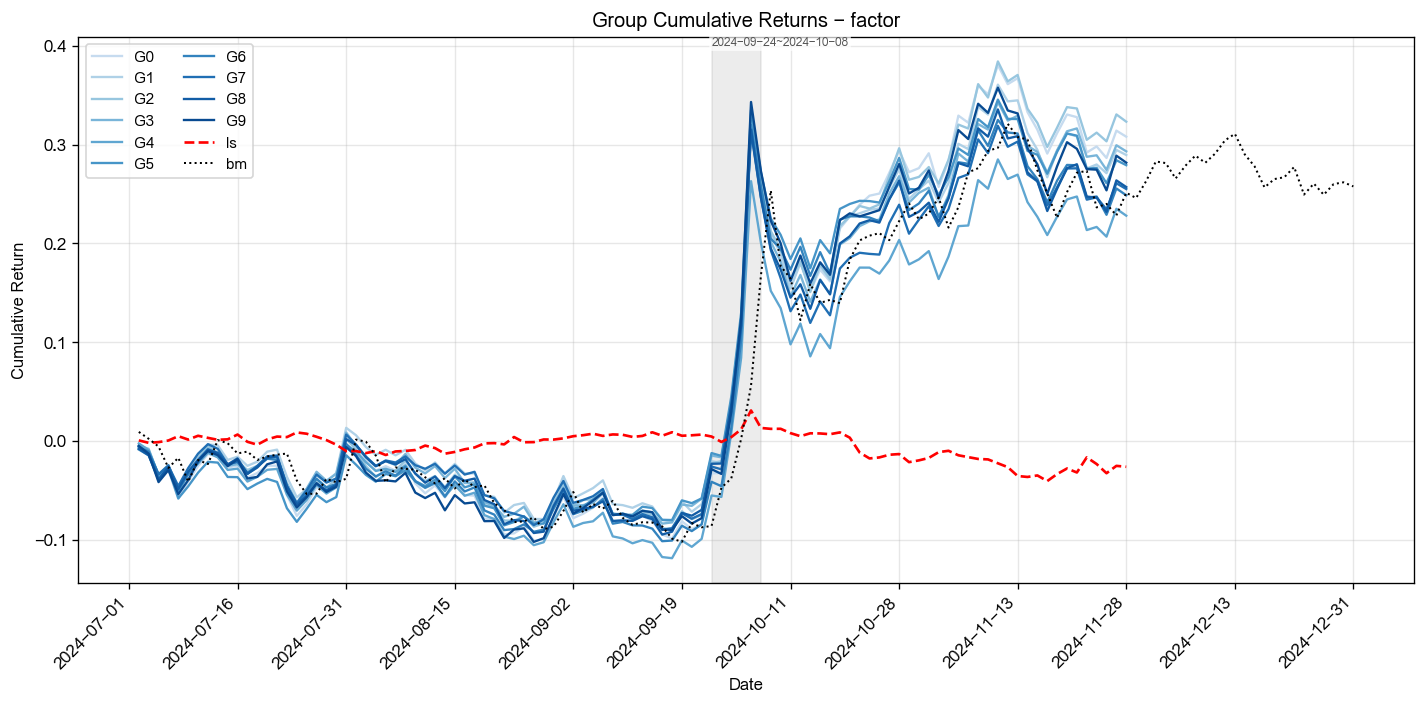
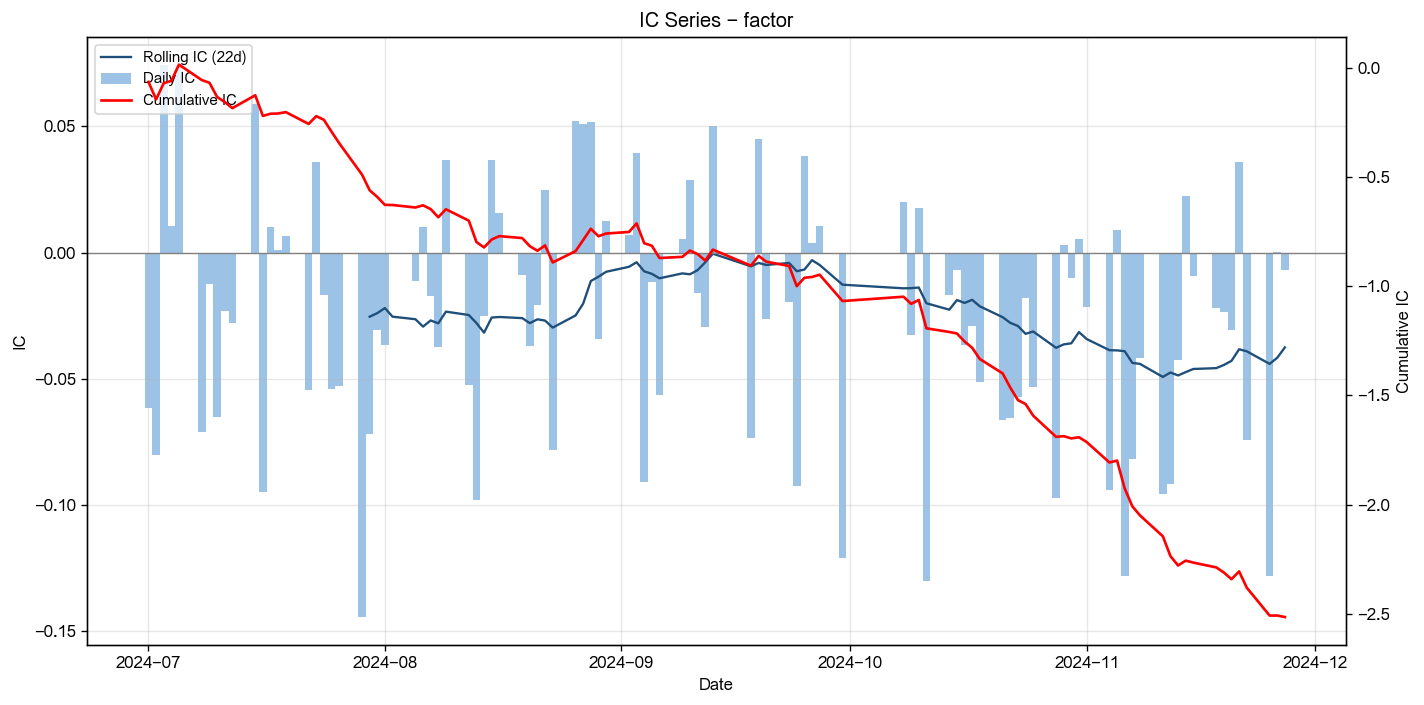
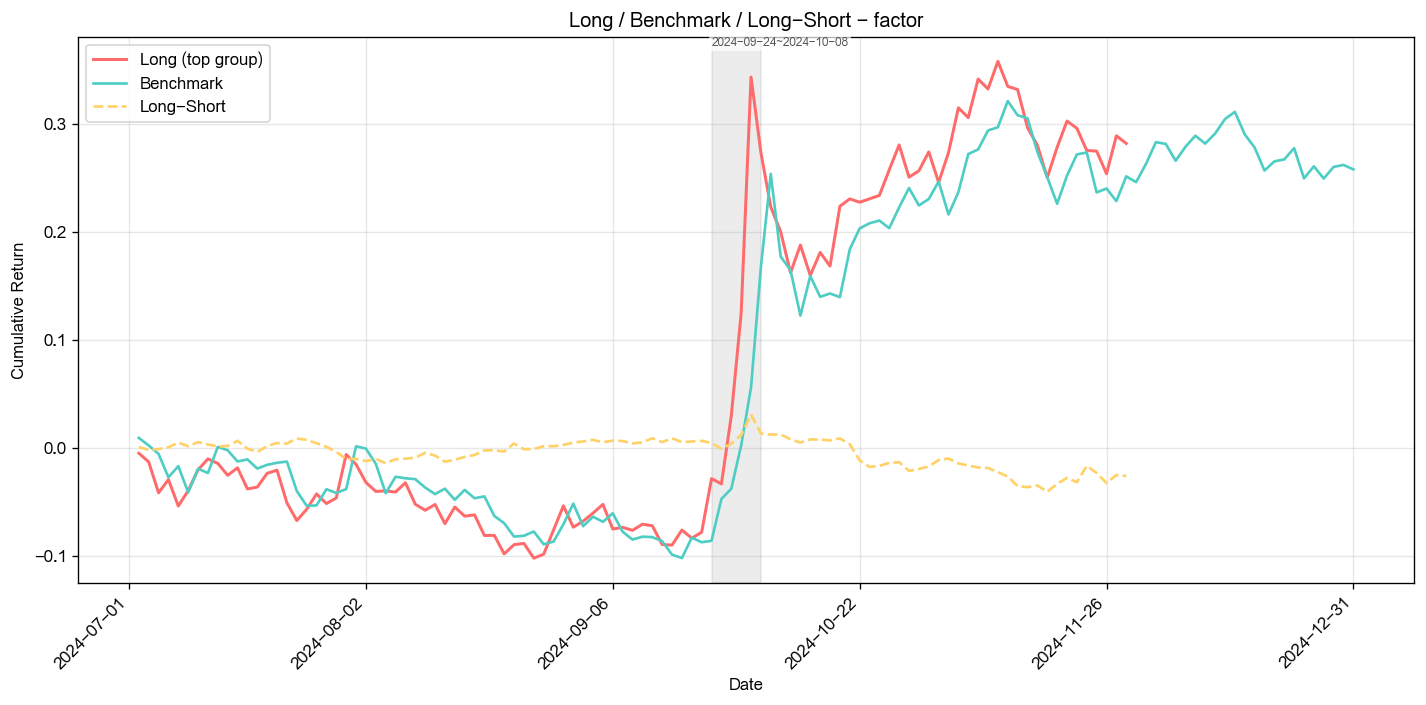
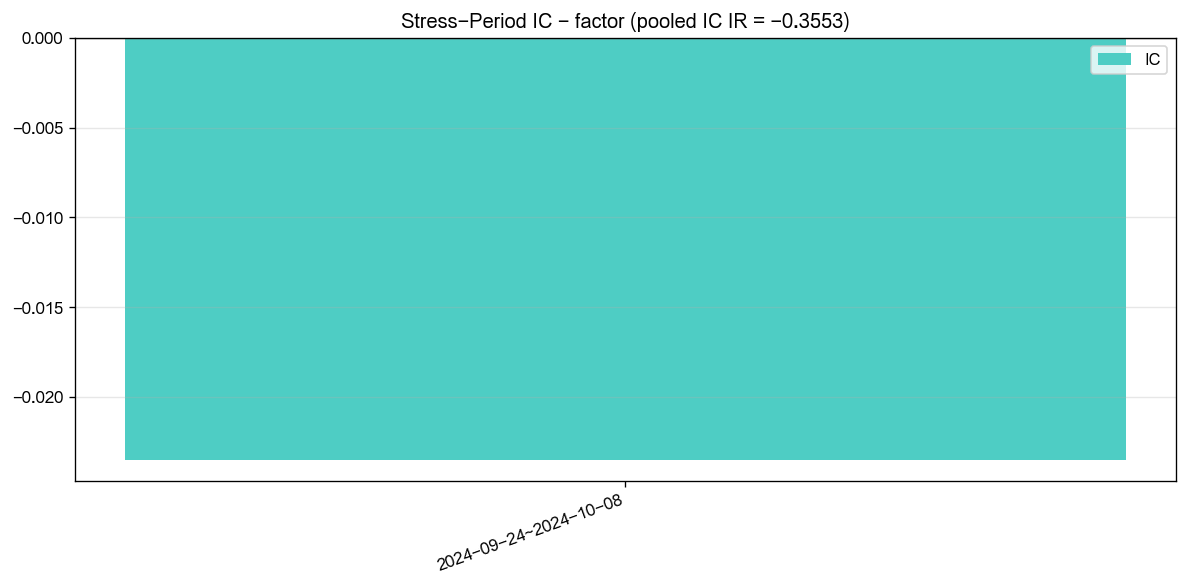
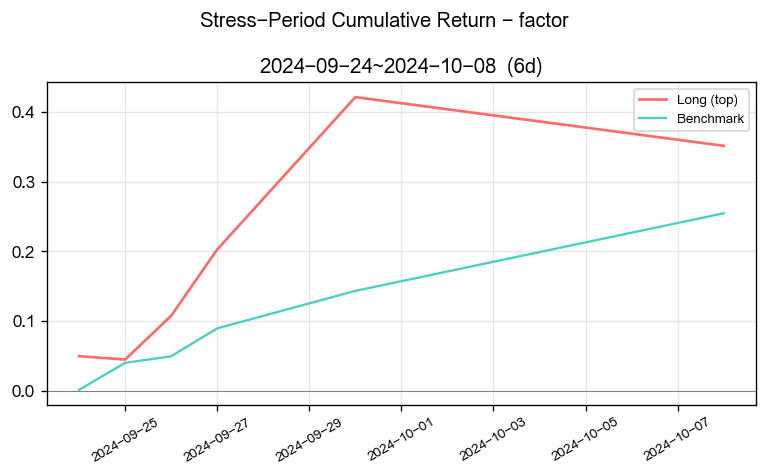

[2026-07-07 16:14:17] [info     ] ========== 因子池回归 ==========
[2026-07-07 16:14:17] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1103 rows=145937 start_date=2024-07-01
[2026-07-07 16:14:17] [info     ] 获取收益率数据, 耗时: 0.4364 秒
[2026-07-07 16:14:18] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.2781 秒
[2026-07-07 16:14:18] [info     ] 统计 回归结果, 耗时: 0.0495 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,cci_14,5.0461,0.0581,0.0115,1.0000
2,volume,3.0777,0.0214,0.0070,1.0000
3,ps_ttm,2.9777,0.0044,0.0015,1.0000
4,macd_hist_12_26_9,2.5320,0.0124,0.0049,1.0000
5,rsi_12,2.4191,0.0550,0.0227,1.0000
6,netflow_amount_main,2.0457,0.0337,0.0165,1.0000
7,turn,1.9749,0.0141,0.0072,1.0000
8,total_market_cap,1.8180,0.0175,0.0097,1.0000
9,pe_ttm,1.7797,0.0050,0.0028,1.0000
10,debt_to_asset_lf,1.7626,0.0050,0.0028,1.0000

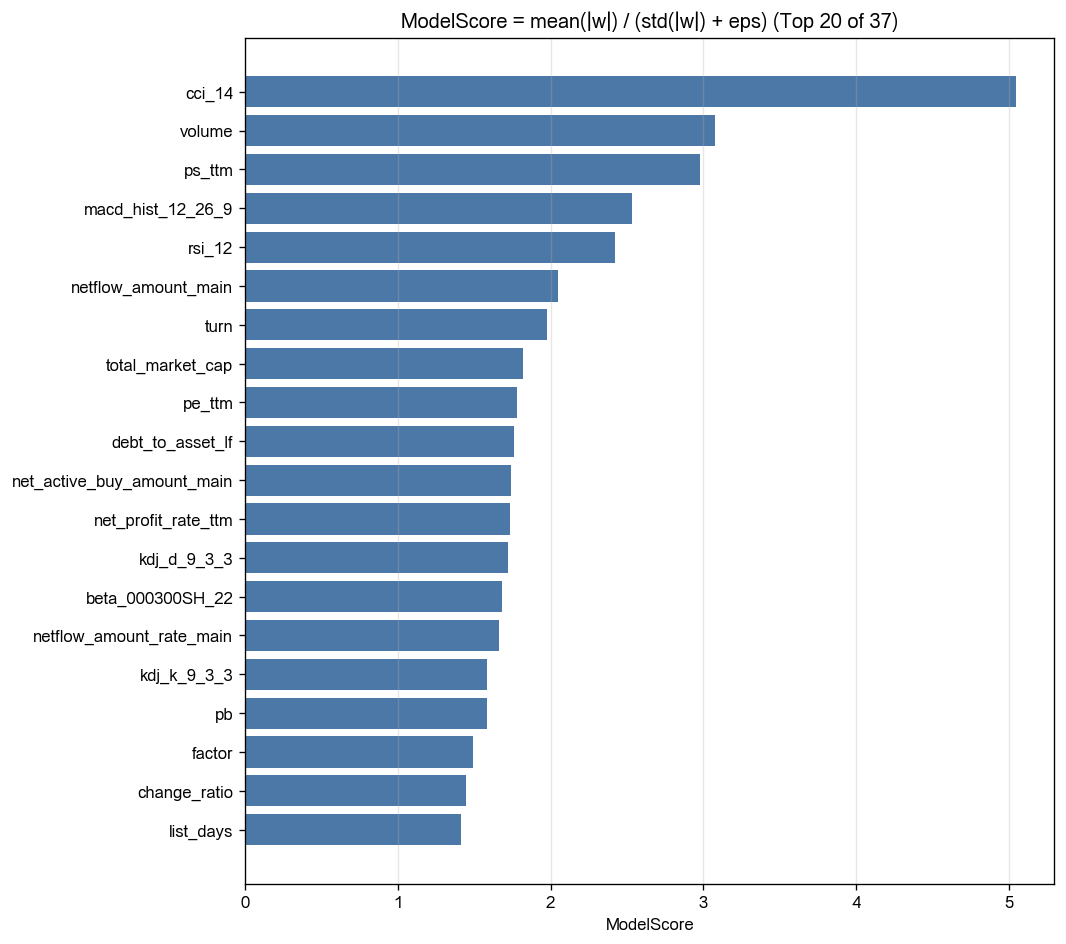
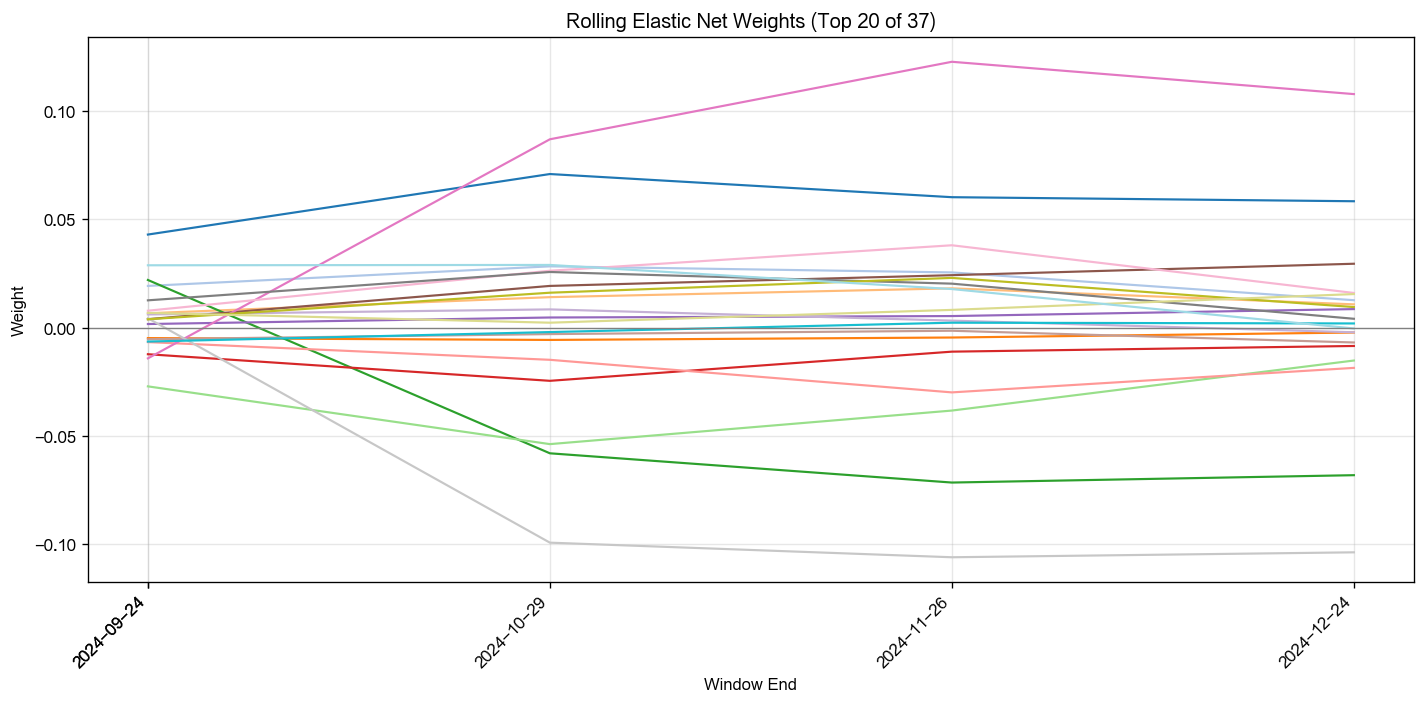
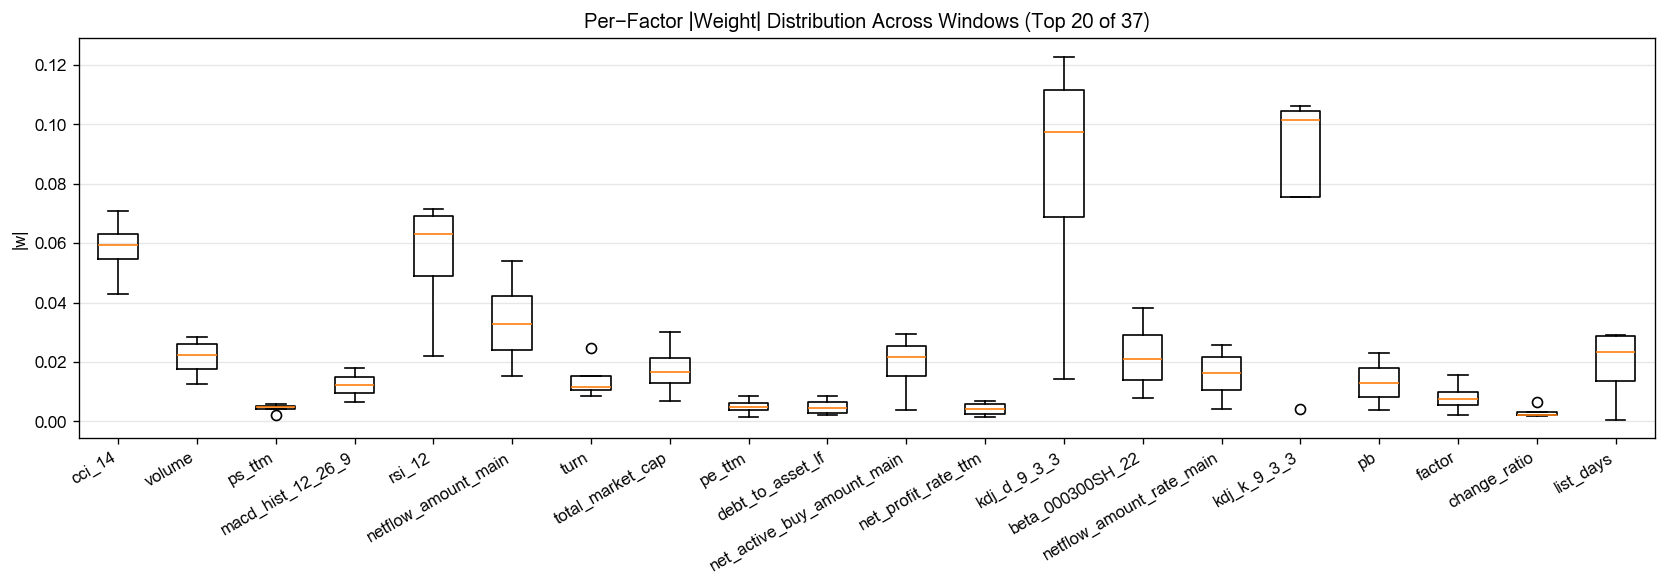
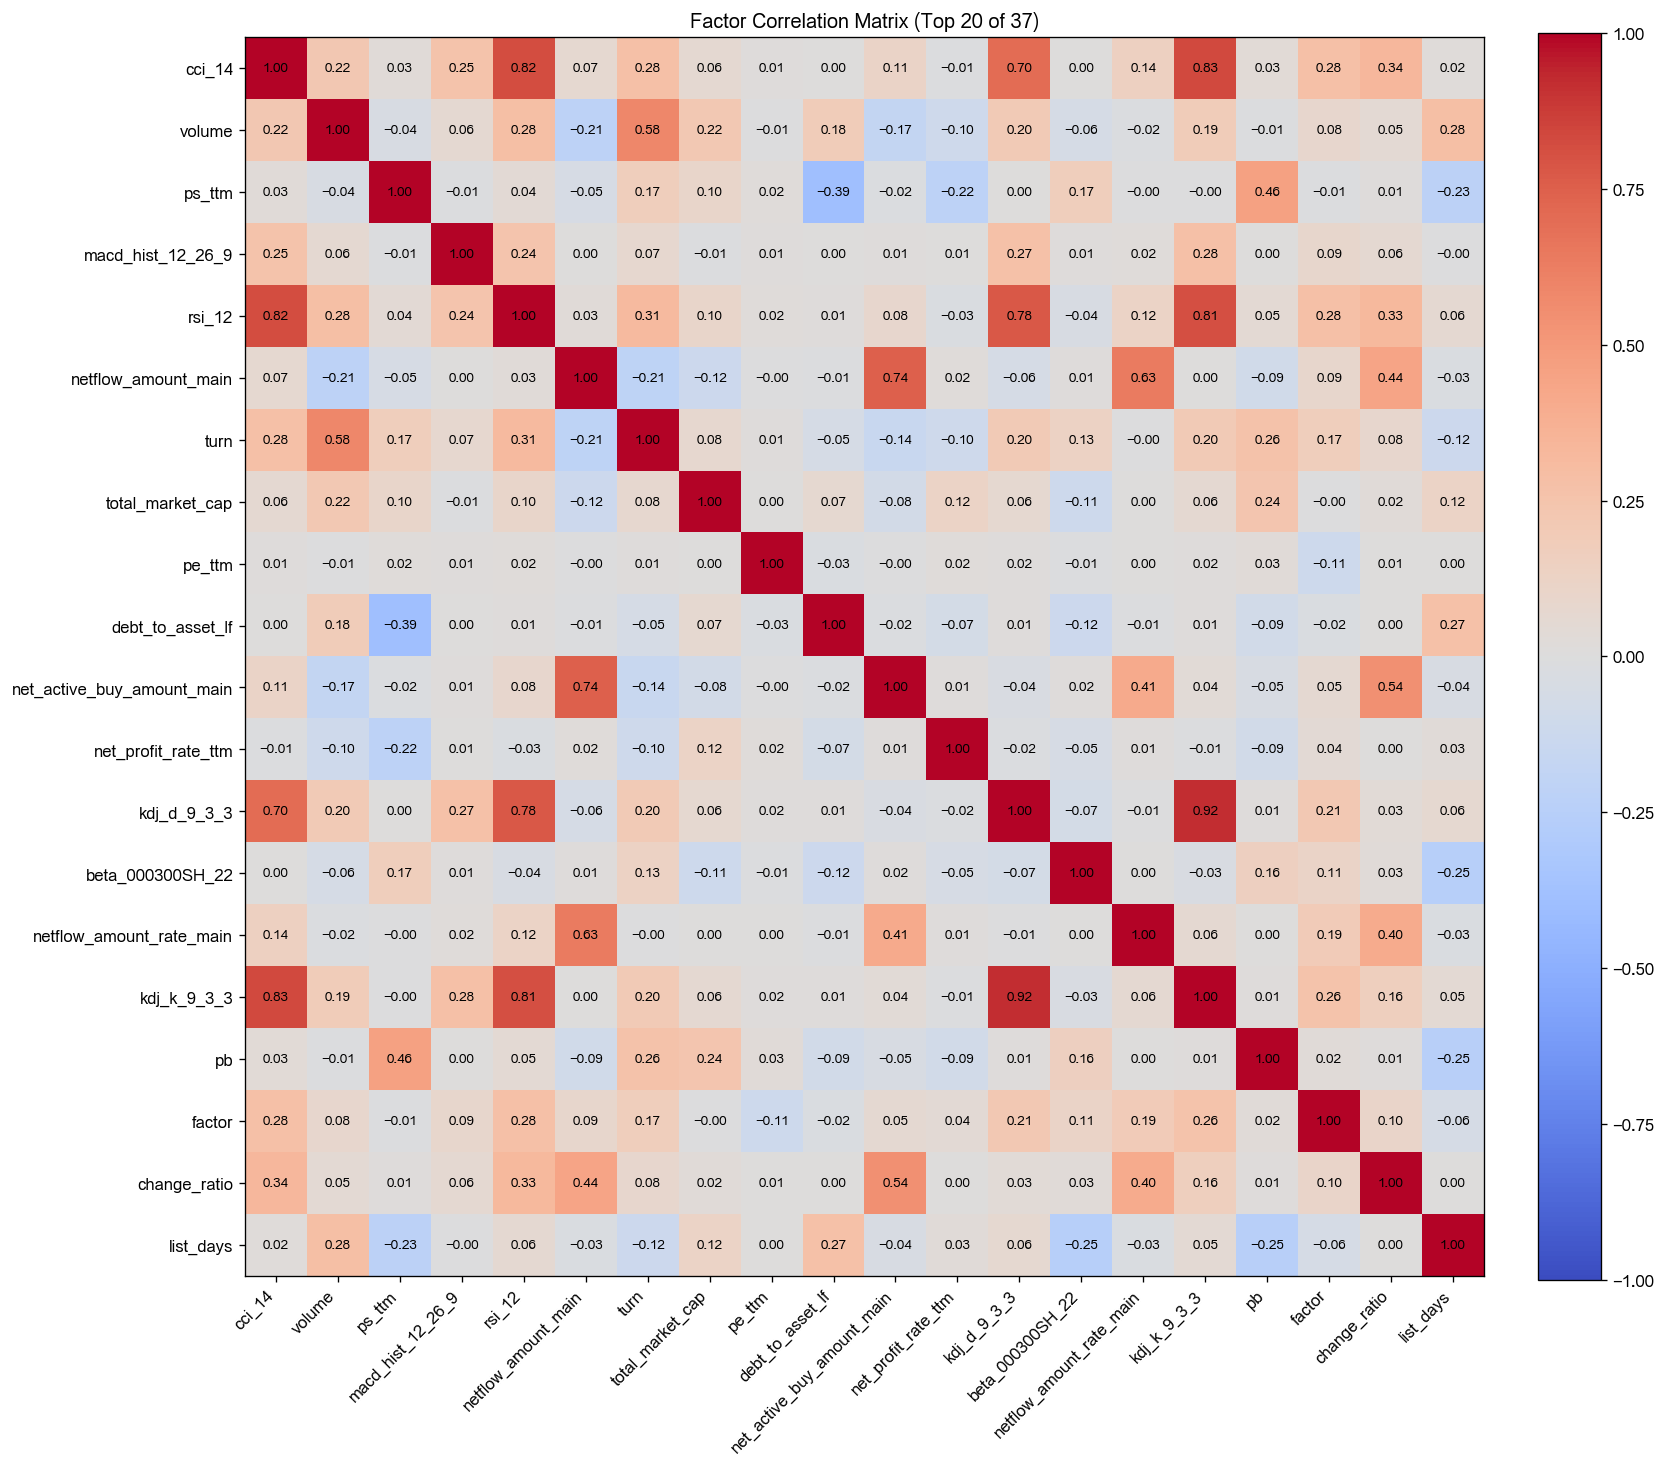

[2026-07-07 16:14:20] [warning  ] 返回的Outputs实例(size=17786459) 大于 64K, 将不会被缓存
[2026-07-07 16:14:20] [info     ] bigalpha_eval.v4 运行完成 [10.872s].


In [2]:
if __name__ == '__main__':
    from bigmodule import M; import dai, structlog
    logger = structlog.get_logger()
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m', 'financial': 'bigalpha_2026_financial'}
    start_date = '2024-07-01 00:00:00'; end_date = '2024-12-31 23:59:59'
    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query("SELECT * FROM bigalpha_2026_factorlib",
                             filters={'date': [start_date, end_date]}).df()
    M.bigalpha_eval._latest(factor_data=factor_data, factor_pool=factor_pool, process_pools=False, show=True)
